In [26]:
#Load bioactivity data
import pandas as pd


In [27]:
df= pd.read_csv('data/bioactivity_preprocessed_data.csv')

(ADME-pharmacokinetic profile)
The Lipinski's Rule of five stated the following:(oral)
 Molecular weight < 500 Dalton
 Octanol-water partition coefficient (LogP) < 5
 Hydrogen bond donors < 5
 Hydrogen bond acceptors < 10

In [28]:
#Libraries
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

ln4:(first for loop)Converts each SMILES string into an RDKit molecule object
ln11:(2nd for loop)Loops throught the molecules computing descriptors
ln18:combines them into a row
ln23:(if statement)-stacks vetically with the row initializing the dataset(outdated style & slow**)

In [29]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

Alternative:||
def lipinski(smiles):
    data = []

    for s in smiles:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            continue

        data.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol)
        ])

    return pd.DataFrame(data, columns=["MW","LogP","NumHDonors","NumHAcceptors"])

In [30]:
df_lipinski = lipinski(df.canonical_smiles)

In [31]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,281.271,1.89262,0.0,5.0
1,415.589,3.81320,0.0,2.0
2,421.190,2.66050,0.0,4.0
3,293.347,3.63080,0.0,3.0
4,338.344,3.53900,0.0,5.0
...,...,...,...,...
254,436.512,1.47440,3.0,4.0
255,496.583,2.73690,3.0,4.0
256,471.985,2.06450,2.0,4.0
257,465.594,2.19130,2.0,4.0


In [32]:
df

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,7200.0
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,9400.0
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,13500.0
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,13110.0
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,2000.0
...,...,...,...,...
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,52.0
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,active,30.0
256,CHEMBL5565685,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,14.0
257,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,48.0


In [33]:
#combining both df 
df_combined = pd.concat([df,df_lipinski], axis=1)

In [34]:
df_combined

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,7200.0,281.271,1.89262,0.0,5.0
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,9400.0,415.589,3.81320,0.0,2.0
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,13500.0,421.190,2.66050,0.0,4.0
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,13110.0,293.347,3.63080,0.0,3.0
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,2000.0,338.344,3.53900,0.0,5.0
...,...,...,...,...,...,...,...,...
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,52.0,436.512,1.47440,3.0,4.0
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,active,30.0,496.583,2.73690,3.0,4.0
256,CHEMBL5565685,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,14.0,471.985,2.06450,2.0,4.0
257,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,48.0,465.594,2.19130,2.0,4.0


Converting IC50 to pIC50 =have even data points by converting it to the ive logarithmic scale (-10Log(IC50))
ln5:Take the IC50 values from the standard_value column and converts it from nM to M by multiplying the value by 10
    Take the molar value and apply -log10
    Delete the standard_value column and create a new pIC50 column


In [35]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)
        
    return x

In [36]:
df_combined.standard_value.describe()
     

count    2.590000e+02
mean     6.526248e+04
std      1.807599e+05
min      1.400000e+01
25%      3.550000e+03
50%      1.400000e+04
75%      4.500000e+04
max      2.000000e+06
Name: standard_value, dtype: float64

Outlier capping (winsorization):
 -Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.
 -Capping the max value so the resulting pIC50 values are not less than 1
norm_value

In [37]:

-np.log10( (10**-9)* 100000000 )
     

np.float64(1.0)

In [38]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [39]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)
        
    return x
     

Alternative:
def norm_value(df):
    df = df.copy()
    
    df['standard_value'] = pd.to_numeric(df['standard_value'])
    
    df['standard_value_norm'] = df['standard_value'].clip(upper=100000000)
    
    return df.drop('standard_value', axis=1)

In [40]:
df_norm = norm_value(df_combined)
df_norm
     

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,281.271,1.89262,0.0,5.0,7200.0
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,415.589,3.81320,0.0,2.0,9400.0
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,421.190,2.66050,0.0,4.0,13500.0
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,293.347,3.63080,0.0,3.0,13110.0
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,338.344,3.53900,0.0,5.0,2000.0
...,...,...,...,...,...,...,...,...
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,436.512,1.47440,3.0,4.0,52.0
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,active,496.583,2.73690,3.0,4.0,30.0
256,CHEMBL5565685,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,471.985,2.06450,2.0,4.0,14.0
257,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,465.594,2.19130,2.0,4.0,48.0


In [41]:
df_norm.standard_value_norm.describe()

count    2.590000e+02
mean     6.526248e+04
std      1.807599e+05
min      1.400000e+01
25%      3.550000e+03
50%      1.400000e+04
75%      4.500000e+04
max      2.000000e+06
Name: standard_value_norm, dtype: float64

In [42]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,281.271,1.89262,0.0,5.0,5.142668
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,415.589,3.81320,0.0,2.0,5.026872
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,421.190,2.66050,0.0,4.0,4.869666
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,293.347,3.63080,0.0,3.0,4.882397
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,338.344,3.53900,0.0,5.0,5.698970
...,...,...,...,...,...,...,...,...
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,436.512,1.47440,3.0,4.0,7.283997
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,active,496.583,2.73690,3.0,4.0,7.522879
256,CHEMBL5565685,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,471.985,2.06450,2.0,4.0,7.853872
257,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,465.594,2.19130,2.0,4.0,7.318759


In [43]:
df_final.pIC50.describe()

count    259.000000
mean       5.003513
std        1.017000
min        2.698970
25%        4.346787
50%        4.853872
75%        5.449815
max        7.853872
Name: pIC50, dtype: float64

In [44]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class
     

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,421.190,2.66050,0.0,4.0,4.869666
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,293.347,3.63080,0.0,3.0,4.882397
5,CHEMBL365134,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c(Br)cccc21,active,372.243,4.39330,0.0,3.0,6.008774
7,CHEMBL190743,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccc(I)cc21,active,419.243,4.23540,0.0,3.0,6.022276
8,CHEMBL365469,O=C1C(=O)N(Cc2cc3ccccc3s2)c2cccc(Cl)c21,inactive,327.792,4.28420,0.0,3.0,4.950782
...,...,...,...,...,...,...,...,...
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,436.512,1.47440,3.0,4.0,7.283997
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,active,496.583,2.73690,3.0,4.0,7.522879
256,CHEMBL5565685,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,471.985,2.06450,2.0,4.0,7.853872
257,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,465.594,2.19130,2.0,4.0,7.318759


Chemical Space Analysis via Lipinski descriptors

In [45]:
import seaborn as sns
sns.set_theme(style='ticks')
import matplotlib.pyplot as plt

Frequency plot of the 2 bioactivity classes

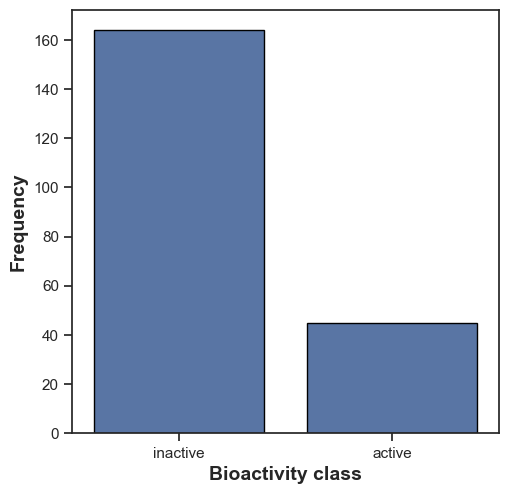

In [46]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

Scatter plot of MW versus LogP

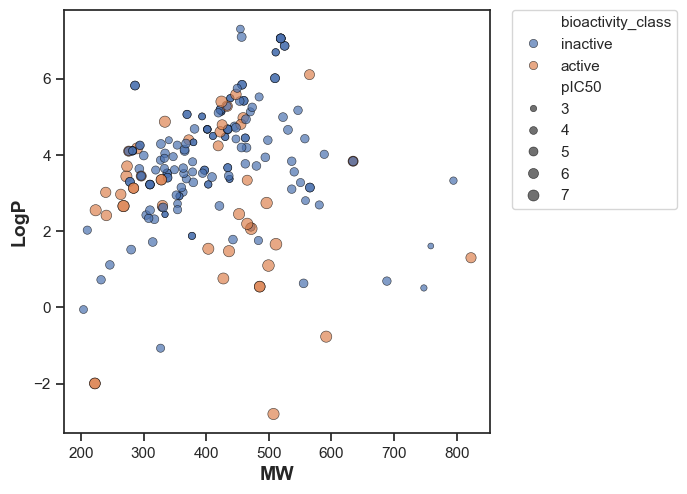

In [47]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

Box plots


pIC50 value

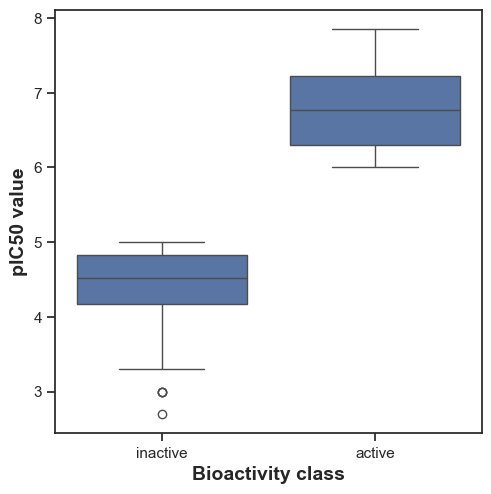

In [48]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')
     

Statistical analysis | Mann-Whitney U Test

In [49]:
def mannwhitney(descriptor, verbose=False):
  
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [50]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,7380.0,9.735838e-25,0.05,Different distribution (reject H0)


MW

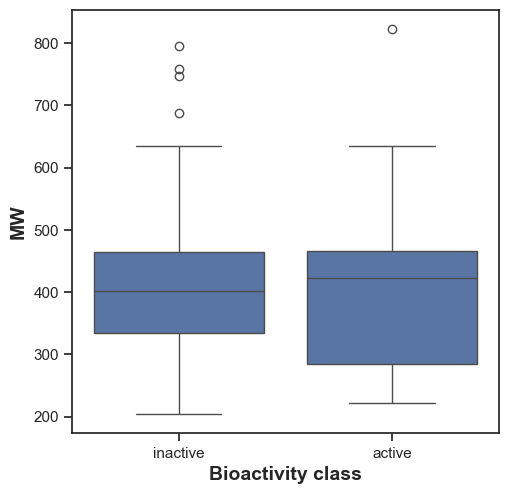

In [51]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')
     

In [52]:

mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,3296.5,0.27413,0.05,Same distribution (fail to reject H0)


LogP

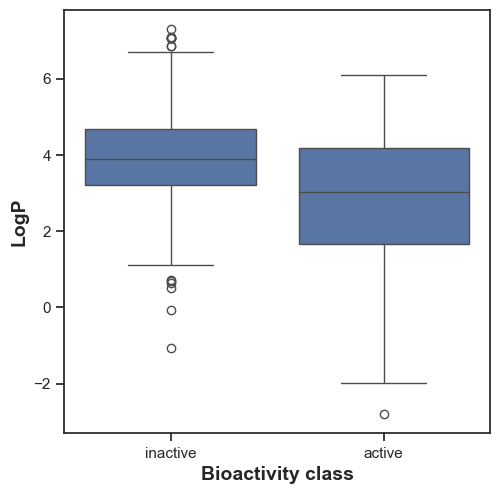

In [53]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

In [54]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,2394.5,0.000314,0.05,Different distribution (reject H0)


NumHDonors

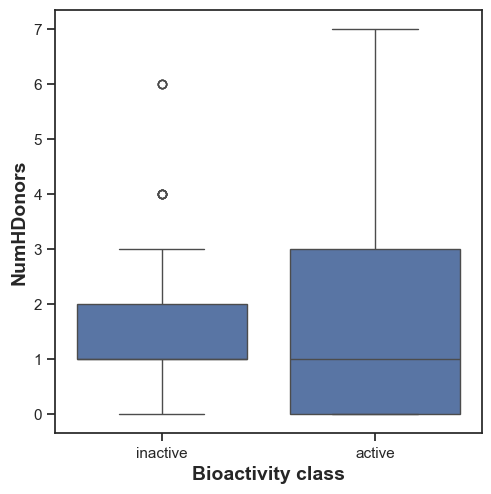

In [55]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

In [56]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3376.0,0.365167,0.05,Same distribution (fail to reject H0)


NumHAcceptors


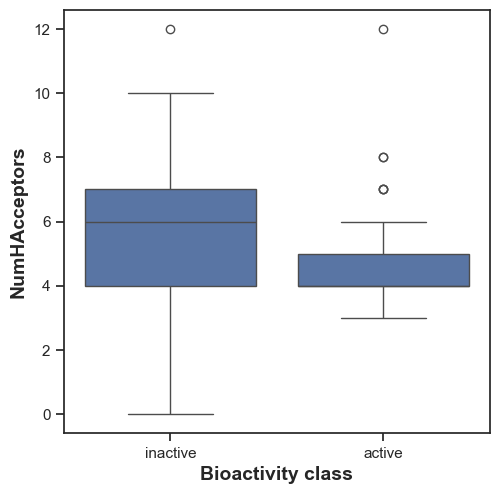

In [57]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [58]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,2747.5,0.007975,0.05,Different distribution (reject H0)


In [59]:
! zip -r results.zip . -i *.csv *.pdf

  adding: mannwhitneyu_NumHAcceptors.csv (deflated 10%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: mannwhitneyu_MW.csv (deflated 7%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: plot_LogP.pdf (deflated 38%)
  adding: plot_MW.pdf (deflated 37%)
  adding: plot_NumHDonors.pdf (deflated 37%)
  adding: plot_NumHAcceptors.pdf (deflated 37%)
  adding: plot_ic50.pdf (deflated 37%)
  adding: mannwhitneyu_pIC50.csv (deflated 11%)
  adding: plot_MW_vs_LogP.pdf (deflated 11%)
  adding: mannwhitneyu_LogP.csv (deflated 8%)
